# Topic 8: Advanced Array Operations in NumPy

In [2]:
import numpy as np
import numpy.linalg as LA
import matplotlib.pyplot as plt
from time import perf_counter

# For reproducibility where randomness is used
rng = np.random.default_rng(42)


## Arrays, views vs. copies

Slicing usually returns a **view** (no data copy). Fancy indexing and boolean masking return **copies**. Modifying a view affects the original array; modifying a copy does not.


In [2]:
a = np.arange(10)
view = a[2:7]       # view
copy_ = a[[2,3,4]]  # copy (fancy indexing)

view[:] = -1
print("After modifying view, a:", a)
copy_[:] = 99
print("After modifying copy, a (unchanged):", a)

After modifying view, a: [ 0  1 -1 -1 -1 -1 -1  7  8  9]
,After modifying copy, a (unchanged): [ 0  1 -1 -1 -1 -1 -1  7  8  9]



## Basic slicing: 1D and 2D

Slicing syntax: `start:stop:step` with any omitted implying the default. Negative indices count from the end; negative steps reverse order.


In [5]:
# 1D
x = np.arange(12)
print("x:", x)
print("x[::2] (every other):", x[::2])
print("x[5:] (tail):", x[5:])
print("x[:-3] (all but last 3):", x[:-3])
print("x[::-1] (reversed):", x[::-1])

# 2D
M = np.arange(1, 1+6*5).reshape(6, 5)
print("M:", M)
print("Rows 1..4, Cols 0..3:", M[1:5, 0:4])
print("Every other row, last 3 cols:", M[::2, -3:])

x: [ 0  1  2  3  4  5  6  7  8  9 10 11]
,x[::2] (every other): [ 0  2  4  6  8 10]
,x[5:] (tail): [ 5  6  7  8  9 10 11]
,x[:-3] (all but last 3): [0 1 2 3 4 5 6 7 8]
,x[::-1] (reversed): [11 10  9  8  7  6  5  4  3  2  1  0]
,M: [[ 1  2  3  4  5]
, [ 6  7  8  9 10]
, [11 12 13 14 15]
, [16 17 18 19 20]
, [21 22 23 24 25]
, [26 27 28 29 30]]
,Rows 1..4, Cols 0..3: [[ 6  7  8  9]
, [11 12 13 14]
, [16 17 18 19]
, [21 22 23 24]]
,Every other row, last 3 cols: [[ 3  4  5]
, [13 14 15]
, [23 24 25]]



## Ellipsis and adding axes

Use `...` to stand in for "as many `:` as needed". Use `None` (or `np.newaxis`) to add a length-1 axis for broadcasting and alignment.


In [6]:
A = np.arange(2*3*4).reshape(2,3,4)
print("A shape:", A.shape)
print("A[..., 1] shape:", A[..., 1].shape)   # take col index 1 on the last axis

v = np.arange(4)
print("v shape:", v.shape)
print("v[None, :] shape:", v[None, :].shape) # add leading axis
print("v[:, None] shape:", v[:, None].shape) # add trailing axis

A shape: (2, 3, 4)
,A[..., 1] shape: (2, 3)
,v shape: (4,)
,v[None, :] shape: (1, 4)
,v[:, None] shape: (4, 1)



## Boolean masks

A boolean mask selects entries where a condition holds. Masks can be combined with logical operations and used for assignment.

**Physics mini-example:** Select timesteps where a projectile is above the ground.

$ x(t) = v_0 \cos\theta\, t $

$ y(t) = v_0 \sin\theta\, t - \tfrac{1}{2} g t^2 $


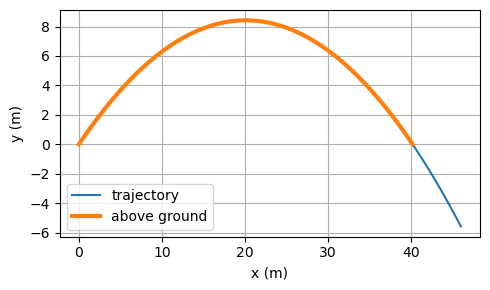

In [7]:
# Parameters
g = 9.81
v0 = 20.0
theta = np.deg2rad(40)
t = np.linspace(0, 3, 301)

x = v0*np.cos(theta)*t
y = v0*np.sin(theta)*t - 0.5*g*t**2

mask = (y >= 0)
x_above = x[mask]
y_above = y[mask]

plt.figure(figsize=(5,3))
plt.plot(x, y, label="trajectory")
plt.plot(x_above, y_above, lw=3, label="above ground")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Fancy (integer) indexing

Fancy indexing uses integer arrays/lists to gather elements in arbitrary order. It returns a copy and can reorder axes depending on usage.


In [8]:
B = np.arange(1, 1+6*5).reshape(6,5)
rows = np.array([0, 2, 5])
cols = np.array([4, 1])
sub = B[rows[:, None], cols[None, :]]  # (3,2) gather
sub

array([[ 5,  2],
       [15, 12],
       [30, 27]])


## Combining basic and advanced indexing

When mixing, **advanced indices are applied first and appear as leading axes** in the result. This can change shape in non-obvious ways.


In [9]:
C = np.arange(3*4*5).reshape(3,4,5)
idx_rows = np.array([2, 0])
# Mix: advanced on axis 0, slice on others
R1 = C[idx_rows, 1:4, 2]
R2 = C[1:3, idx_rows, 2]  # different meaning: advanced is on axis 1
R1.shape, R2.shape

((2, 3), (2, 2))


## Building submatrices with `np.ix_`

`np.ix_` turns 1D index arrays into a broadcastable mesh, preserving 2D structure for row/column selection.


In [13]:
D = np.arange(8*8).reshape(8,8)
print(D)
rows = np.array([1,3,6])
cols = np.array([0,4,7])
D[np.ix_(rows, cols)]

[[ 0  1  2  3  4  5  6  7]
, [ 8  9 10 11 12 13 14 15]
, [16 17 18 19 20 21 22 23]
, [24 25 26 27 28 29 30 31]
, [32 33 34 35 36 37 38 39]
, [40 41 42 43 44 45 46 47]
, [48 49 50 51 52 53 54 55]
, [56 57 58 59 60 61 62 63]]


array([[ 8, 12, 15],
       [24, 28, 31],
       [48, 52, 55]])

In [14]:
F = np.zeros((6,6), dtype=int)
# Set boundary conditions on a 2D grid (e.g., fixed potential at the edges)
F[0, :] = 1
F[-1, :] = 1
F[:, 0] = 2
F[:, -1] = 2
# Raise values in a checkerboard pattern via slicing with steps
F[1::2, 1::2] += 5
F

array([[2, 1, 1, 1, 1, 2],
       [2, 5, 0, 5, 0, 7],
       [2, 0, 0, 0, 0, 2],
       [2, 5, 0, 5, 0, 7],
       [2, 0, 0, 0, 0, 2],
       [2, 6, 1, 6, 1, 7]])


## Physics examples focused on indexing and slicing

**1) Selecting particles in a spherical shell.** With positions $\mathbf{r}_p$ and masses $m_p$, select particles with radii in a band and compute their mean kinetic energy.

$ r_p = \sqrt{x_p^2 + y_p^2 + z_p^2} $

$ K_p = \tfrac{1}{2} m_p v_p^2 $


In [15]:
P = 2000
r = rng.normal(size=(P,3))              # positions
v = rng.normal(size=(P,3))              # velocities
m = rng.uniform(0.1, 5.0, size=P)

rad = np.sqrt((r*r).sum(axis=1))
speed2 = (v*v).sum(axis=1)
K = 0.5*m*speed2

mask_shell = (rad >= 0.5) & (rad < 1.5)
K_shell_mean = K[mask_shell].mean()
K_shell_mean

3.9484833200972838


## Pitfalls and performance notes

- **Views vs copies:** Slices are views; fancy/boolean indexing makes copies. Assign into slices for in-place edits.
- **Chained indexing:** Prefer single, combined indexing (e.g., `A[i, j]`) over chaining (e.g., `A[i][j]`) to avoid accidental copies.
- **Shape surprises:** When mixing basic and advanced indexing, advanced-indexed axes move to the front—use `np.ix_` if you want row/column structure preserved.
- **Memory:** Fancy indexing on large arrays can allocate big temporaries. Consider masks + `np.where` or structured slicing.


In [ ]:
# Create a sample 2D array (e.g., measurements at times and sensors)
A = np.arange(1, 1+6*5).reshape(6, 5)
A

In [ ]:
# Boolean mask: select rows whose mean exceeds a threshold
row_means = A.mean(axis=1)
mask = row_means > row_means.mean()
A[mask]

In [ ]:
# Fancy indexing: gather specific rows and columns in custom order
rows = np.array([0, 2, 5])
cols = np.array([4, 1])
A[rows[:, None], cols[None, :]]  # shape (3,2)

In [ ]:
# np.ix_: build a submatrix from row/col index arrays, preserving 2D structure
rows = np.array([1, 3, 4])
cols = np.array([0, 2])
A[np.ix_(rows, cols)]

In [ ]:
# Broadcasting with None / np.newaxis
v = np.array([10, 20, 30])  # 1D
M = np.arange(12).reshape(4, 3)
M + v  # v is broadcast across rows (4,3) + (3,) -> (4,3)

In [16]:
# Ordered gather with take_along_axis
B = np.array([[5, 1, 9],
              [2, 7, 6]])
# Indices that sort along axis 1 (per row)
idx = np.argsort(B, axis=1)
sorted_B = np.take_along_axis(B, idx, axis=1)
# Scatter back the largest element into a zeros array using put_along_axis
out = np.zeros_like(B)
max_idx = np.argmax(B, axis=1)[:, None]
np.put_along_axis(out, max_idx, np.take_along_axis(B, max_idx, axis=1), axis=1)
(sorted_B, out)

(array([[1, 5, 9],
        [2, 6, 7]]),
 array([[0, 0, 9],
        [0, 7, 0]]))


## Classical mechanics example 1 — Projectile motion (vectorized)

We evaluate many trajectories at once using broadcasting. The kinematics in a uniform gravitational field with no drag are:

$ x(t) = v_0 \cos\theta\; t $

$ y(t) = v_0 \sin\theta\; t - \tfrac{1}{2} g t^2 $

We'll compute trajectories for multiple launch angles at once and select only times above the ground with a boolean mask.


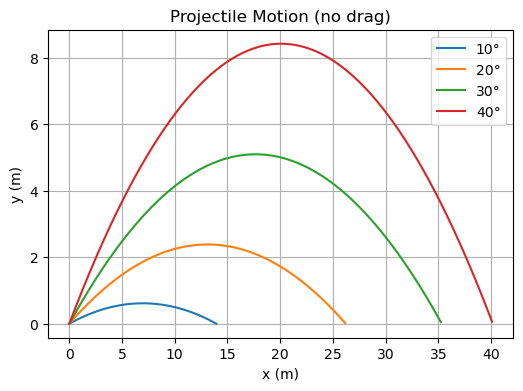

In [17]:
# Parameters
v0 = 20.0  # m/s
g = 9.81   # m/s^2
angles_deg = np.linspace(10, 80, 8)  # 8 launch angles
angles = np.deg2rad(angles_deg)

# Time grid
T = 3.0
N = 501
t = np.linspace(0, T, N)

# Broadcast to shape (angles, time)
# angles[:, None] has shape (8,1), t[None, :] has shape (1, N)
x = v0 * np.cos(angles)[:, None] * t[None, :]
y = v0 * np.sin(angles)[:, None] * t[None, :] - 0.5 * g * t[None, :]**2

# Mask where y >= 0
mask = y >= 0
x_ground = np.where(mask, x, np.nan)
y_ground = np.where(mask, y, np.nan)

# Plot a subset
plt.figure(figsize=(6,4))
for i, th in enumerate(angles_deg[:4]):
    plt.plot(x_ground[i], y_ground[i], label=f"{th:.0f}°")
plt.xlabel("x (m)"); plt.ylabel("y (m)"); plt.title("Projectile Motion (no drag)")
plt.legend(); plt.grid(True)
plt.show()


## Vector operations: dot, norm, cross, outer

$ \textbf{v}\cdot\textbf{w} = \sum_i v_i w_i $

$ \lVert \textbf{v} \rVert = \sqrt{\textbf{v}\cdot\textbf{v}} $

$ \textbf{v}\times\textbf{w} \;\text{(in 3D)} $

$ \text{outer}(\textbf{v}, \textbf{w})_{ij} = v_i w_j $

**Physics example:** Kinetic energy and angular momentum for many particles.

$ K = \tfrac{1}{2} m \lVert\textbf{v}\rVert^2 $

$ \textbf{L} = \sum_{p} \textbf{r}_p \times (m_p \textbf{v}_p) $


In [10]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# simplest cases of dot product, norm, cross product, outer product
print("inner product:", np.inner(a, b))
print("norm:", np.linalg.norm(a))
print("cross product:", np.cross(a, b))
print("outer product:", np.outer(a, b))

inner product: 32
norm: 3.7416573867739413
cross product: [-3  6 -3]
outer product: [[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]


In [18]:
# Many particles in 3D
P = 1000
r = rng.normal(size=(P, 3))  # positions
v = rng.normal(size=(P, 3))  # velocities
m = rng.uniform(0.1, 5.0, size=P)  # masses

# Kinetic energies (vectorized)
speeds2 = np.einsum('ij,ij->i', v, v)  # row-wise dot
K = 0.5 * m * speeds2
K.mean(), K.min(), K.max()

(4.060240505705625, 0.004451398679528187, 35.45939120532477)

In [19]:
# Total angular momentum (vectorized cross products)
L = np.cross(r, (m[:, None] * v), axis=1).sum(axis=0)
L

array([-92.18215652, 144.39399805, 160.77286603])


### Vector Operation Examples

For $N$ time samples of position $\vec{r}(t)$ and velocity $\vec{v}(t)$ (mass $m$), compute:
- Speed $v=\|\vec{v}\|$ and kinetic energy $K=\frac{1}{2}m v^2$.
- Momentum $\vec{p}=m\,\vec{v}$ and angular momentum $\vec{L}=\vec{r}\times\vec{p}$ (in 3D with $z=0$).

We’ll compute these **without loops**.


In [21]:
# Use a moderate N for display
N2 = 2000
T2 = 3.0
r0 = 5.0
t2 = np.linspace(0, T2, N2)
a = np.array([0.0, -g])
r2 = r0 + v0*t2[:,None] + 0.5*a*(t2[:,None]**2)
v2 = v0 + a*t2[:,None]

m = 0.145  # baseball (kg)
speed = np.linalg.norm(v2, axis=1)
K = 0.5*m*speed**2
p = m*v2  # (N2,2)

# Promote to 3D to compute cross product with z=0
r3 = np.column_stack([r2, np.zeros(N2)])
p3 = np.column_stack([p , np.zeros(N2)])
L = np.cross(r3, p3)      # (N2,3)
Lz = L[:,2]
print('K shape:', K.shape, '| Lz shape:', Lz.shape, '| Lz sample:', Lz[:5])

K shape: (2000,) | Lz shape: (2000,) | Lz sample: [ 0.         -0.01070575 -0.02147557 -0.03230947 -0.04320744]



## Matrix operations: matrix–vector, matrix–matrix, determinant

$ \mathbf{y} = \mathbf{A} \, \mathbf{x} $

$ \mathbf{C} = \mathbf{A} \, \mathbf{B} $

$ \det(\mathbf{A}) $

Use `@` or `np.matmul` for matrix products. Determinants via `np.linalg.det`.

**Physics example:** 2D rotation matrix acting on many vectors.

$ \mathbf{R}(\phi) = \begin{bmatrix}\cos\phi & -\sin\phi \\ \sin\phi & \cos\phi \end{bmatrix} $

$ \det(\mathbf{R}) = 1 $


In [22]:
# Rotation of many 2D vectors by many angles (batched matmul)
M = 500  # number of vectors
vecs = rng.normal(size=(M, 2))
phis = np.linspace(0, np.pi, 50)

# Build a stack of rotation matrices of shape (50, 2, 2)
R = np.stack([
    np.array([[np.cos(phi), -np.sin(phi)],
              [np.sin(phi),  np.cos(phi)]])
    for phi in phis
])

# Apply to all vectors: result shape (50, M, 2)
rotated = R @ vecs.T  # (50,2,2) @ (2,M) -> (50,2,M)
rotated = np.swapaxes(rotated, 1, 2)  # (50,M,2)

# Determinants (should all be ~1)
dets = LA.det(R)
dets.min(), dets.max()

(0.9999999999999998, 1.0000000000000002)

In [23]:
# Matrix-vector and matrix-matrix examples
A = rng.normal(size=(4, 4))
x = rng.normal(size=4)
B = rng.normal(size=(4, 3))

Ax = A @ x           # matrix-vector
C = A @ B            # matrix-matrix
DetA = LA.det(A)
Ax, C.shape, DetA

(array([ 3.7201025 , -2.6474326 ,  3.34752917, -4.89938424]),
 (4, 3),
 -3.0693631187799446)


### Generalized/batched matrix products
When you have batches (stacks) of matrices/vectors, broadcasting with `@` or `np.einsum` is handy.

$ C_{b i j} = \sum_k A_{b i k} B_{b k j} $

$ y_{b i} = \sum_j A_{b i j} x_{b j} $


In [24]:
# Batched example: multiply a batch of matrices by a batch of vectors
BATCH, N = 64, 32
A_batch = rng.normal(size=(BATCH, N, N))
x_batch = rng.normal(size=(BATCH, N))

# Using einsum (explicit index notation)
y1 = np.einsum('bij,bj->bi', A_batch, x_batch)

# Using @ with broadcasting by adding axis to x
y2 = A_batch @ x_batch[..., None]
y2 = y2[..., 0]

np.allclose(y1, y2)

True


## Classical mechanics example 2 — Harmonic oscillator (vectorized evaluation)

$ m\ddot{x} + k x = 0 $

$ \omega = \sqrt{k/m} $

$ x(t) = A \cos(\omega t) + B \sin(\omega t) $

We'll evaluate many parameter sets ($m,k,A,B$) and times at once.


In [25]:
# Parameter ensembles
Msets = 200
m = rng.uniform(0.5, 2.0, size=Msets)
k = rng.uniform(0.5, 5.0, size=Msets)
omega = np.sqrt(k / m)
A = rng.normal(size=Msets)
B = rng.normal(size=Msets)

# Time grid
t = np.linspace(0, 10, 2000)

# Vectorized evaluation -> shape (Msets, T)
x = A[:, None] * np.cos(omega[:, None] * t[None, :]) +     B[:, None] * np.sin(omega[:, None] * t[None, :])

x.shape, np.mean(x)

((200, 2000), -0.002967554730257597)

## Loops versus Vectorized (Numpy Array) Operations

### Data We'll Use
We'll create some arrays to work with. We'll also set a random seed for reproducibility.

In [6]:
import numpy as np

rng = np.random.default_rng(2024)

# Sizes chosen to be reasonably quick in the classroom
N = 2000
x = rng.normal(loc=0.0, scale=2.0, size=N)   # a 1D array (e.g., measurement noise)
y = rng.normal(loc=5.0, scale=1.0, size=N)   # another 1D array

# Smaller arrays for 2D/broadcasting demos
M = 200
a = np.linspace(-2.0, 2.0, M)
b = np.linspace( 0.0, 3.0, M)


### Summation
**Problem.** Compute the sum of an array $x_1,\dots,x_N$:

$ S = \sum_{i=1}^{N} x_i. $


In [9]:
# Loop version
def sum_loop(arr):
    s = 0.0
    for v in arr:
        s += v
    return s

# Vectorized / NumPy version
def sum_np(arr):
    return np.sum(arr)

# Compare
print(sum_loop(x))
print(sum_np(x))

-73.83052561593662
-73.83052561593658



### Mean
**Problem.** Compute the mean of an array $x_1,\dots,x_N$:

$ \bar{x} = \dfrac{1}{N} \sum_{i=1}^{N} x_i. $


In [10]:
# Loop version (2-pass for clarity)
def mean_loop(arr):
    s = 0.0
    n = 0
    for v in arr:
        s += v
        n += 1
    return s / n

# Vectorized
def mean_np(arr):
    return np.mean(arr)

print(mean_loop(x))
print(mean_np(x))

-0.036915262807968315
-0.03691526280796829



### Median
**Problem.** The median $m$ satisfies $\#\{i: x_i \le m\} \ge N/2$ and $\#\{i: x_i \ge m\} \ge N/2$. For even $N$, a common definition is the midpoint of the two central order statistics.


In [13]:
# Plain Python approach using sorting (not vectorized)
def median_python(arr):
    data = sorted(arr)  # converts to Python list and sorts
    n = len(data)
    mid = n // 2
    if n % 2 == 1:
        return float(data[mid])
    else:
        return 0.5*(data[mid-1] + data[mid])

# NumPy version
def median_np(arr):
    return float(np.median(arr))

# Use a smaller slice for fair timing of the pure-Python sort
print(median_python(x))
print(median_np(x))

-0.06643642810722451
-0.06643642810722451



### Elementwise Multiplication and Dot Product
**Problem.** Compute $w_i = x_i\,y_i$ and the dot product $x\cdot y = \sum_{i=1}^{N} x_i y_i$.


In [16]:
x1 = rng.normal(loc=0.0, scale=2.0, size=10)   # a 1D array (e.g., measurement noise)
y1 = rng.normal(loc=5.0, scale=1.0, size=10)   # another 1D array


# Loop versions
def multiply_loop(a, b):
    out = []
    for ai, bi in zip(a, b):
        out.append(ai*bi)
    return out

def dot_loop(a, b):
    s = 0.0
    for ai, bi in zip(a, b):
        s += ai*bi
    return s

# Vectorized
def multiply_np(a, b):
    return a * b

def dot_np(a, b):
    return float(np.dot(a, b))

print(multiply_loop(x1, y1))
print(multiply_np(x1, y1))

print(dot_loop(x, y))
print(dot_np(x, y))

[np.float64(8.797894238027805), np.float64(-3.8592847545809237), np.float64(7.479806543557268), np.float64(0.9824891375193895), np.float64(5.016099108880386), np.float64(6.222759503441147), np.float64(7.720422929869739), np.float64(12.43886742652563), np.float64(-10.895762303179142), np.float64(-1.0736766056307758)]
[  8.79789424  -3.85928475   7.47980654   0.98248914   5.01609911
   6.2227595    7.72042293  12.43886743 -10.8957623   -1.07367661]
-418.9113105188791
-418.9113105188791



### Building Sequences
**Problem.** Build sequences like $x_i = a + i\,\Delta$ or $x_i$ evenly spaced between two endpoints.


In [17]:
# Loop: arithmetic progression
def arith_progression_loop(a, step, n):
    seq = []
    cur = a
    for _ in range(n):
        seq.append(cur)
        cur += step
    return np.array(seq)

# Vectorized
def arith_progression_np(a, step, n):
    return a + step*np.arange(n)

# Loop vs np.linspace for even spacing between endpoints
def linspace_loop(start, stop, n):
    if n == 1:
        return np.array([start])
    step = (stop - start)/(n-1)
    return arith_progression_loop(start, step, n)

start, stop, n = -3.0, 2.0, 11
print(arith_progression_loop(start, 0.5, n))
print(arith_progression_np(start, 0.5, n))

print(linspace_loop(start, stop, n))
print(np.linspace(start, stop, n))

[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]
[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]
[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]
[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]



### Boolean Masking (Filtering)
**Problem.** Compute the fraction of values above a threshold $t$:

$ f = \dfrac{1}{N} \sum_{i=1}^{N} \mathbf{1}_{\{x_i > t\}}. $


In [18]:
# Loop
def frac_above_loop(arr, t):
    c = 0
    n = 0
    for v in arr:
        n += 1
        if v > t:
            c += 1
    return c / n

# Vectorized
def frac_above_np(arr, t):
    return np.mean(arr > t)

thr = 0.75
print(frac_above_loop(x, thr))
print(frac_above_np(x, thr))

0.3495
0.3495



### Cumulative Sums and Running Averages
**Problem.** Compute the cumulative sums $S_n = \sum_{i=1}^{n} x_i$ and the running average $A_n = \dfrac{S_n}{n}$.


In [ ]:

# Loop cumulative sum

def cumsum_loop(arr):
    out = np.empty_like(arr)
    s = 0.0
    for i, v in enumerate(arr):
        s += v
        out[i] = s
    return out

# Vectorized

def cumsum_np(arr):
    return np.cumsum(arr)

lt, cs_loop = time_fn(cumsum_loop, x)
nt, cs_np   = time_fn(cumsum_np,   x)
print(f"cumsum equal? {close(cs_loop, cs_np)} | loop: {lt:.4f}s vs numpy: {nt:.4f}s")

# Running average
A_loop = cs_loop / np.arange(1, len(x)+1)
A_np   = cs_np   / np.arange(1, len(x)+1)
print(f"running avg equal? {close(A_loop, A_np)}")



## Example: Avoiding loops & timing — projectile ensembles

We compare pure-Python loops to NumPy vectorization for many projectiles and time points.

$ x(t) = v_0 \cos\theta\; t $

$ y(t) = v_0 \sin\theta\; t - \tfrac{1}{2} g t^2 $


In [3]:
# Problem size
P = 2000   # projectiles
T = 1500   # time points
v0 = 30.0
angles = rng.uniform(low=0.05*np.pi, high=0.95*np.pi/2, size=P)
t = np.linspace(0, 5.0, T)
g = 9.81

# Loop implementation
def projectile_loops(v0, angles, t, g):
    P = len(angles)
    T = len(t)
    x = np.empty((P, T))
    y = np.empty((P, T))
    for i in range(P):
        c = np.cos(angles[i])
        s = np.sin(angles[i])
        for j in range(T):
            x[i, j] = v0 * c * t[j]
            y[i, j] = v0 * s * t[j] - 0.5 * g * t[j]*t[j]
    return x, y

def projectile_semivectorized(v0, angles, t, g):
    P = len(angles)
    T = len(t)
    x = np.empty((P, T))
    y = np.empty((P, T))
    for i in range(P):
        c = np.cos(angles[i])
        s = np.sin(angles[i])
        x[i, :] = v0 * c * t
        y[i, :] = v0 * s * t - 0.5 * g * t * t
    return x, y

# Vectorized implementation
def projectile_vectorized(v0, angles, t, g):
    x = v0 * np.cos(angles)[:, None] * t[None, :]
    y = v0 * np.sin(angles)[:, None] * t[None, :] - 0.5 * g * t[None, :]**2
    return x, y

# Sanity check
print(projectile_loops(v0, angles[:3], t[:5], g))
print(projectile_semivectorized(v0, angles[:3], t[:5], g))
print(projectile_vectorized(v0, angles[:3], t[:5], g))

(array([[0.        , 0.03714917, 0.07429834, 0.11144752, 0.14859669],
       [0.        , 0.07368931, 0.14737861, 0.22106792, 0.29475722],
       [0.        , 0.02643398, 0.05286796, 0.07930195, 0.10573593]]), array([[0.        , 0.0928609 , 0.18561266, 0.27825527, 0.37078874],
       [0.        , 0.06764501, 0.13518086, 0.20260758, 0.26992515],
       [0.        , 0.09645756, 0.19280597, 0.28904524, 0.38517536]]))
(array([[0.        , 0.03714917, 0.07429834, 0.11144752, 0.14859669],
       [0.        , 0.07368931, 0.14737861, 0.22106792, 0.29475722],
       [0.        , 0.02643398, 0.05286796, 0.07930195, 0.10573593]]), array([[0.        , 0.0928609 , 0.18561266, 0.27825527, 0.37078874],
       [0.        , 0.06764501, 0.13518086, 0.20260758, 0.26992515],
       [0.        , 0.09645756, 0.19280597, 0.28904524, 0.38517536]]))
(array([[0.        , 0.03714917, 0.07429834, 0.11144752, 0.14859669],
       [0.        , 0.07368931, 0.14737861, 0.22106792, 0.29475722],
       [0.        , 0.0

In [28]:
%%timeit -n 3 -r 3
x_loop, y_loop = projectile_loops(v0, angles, t, g)

2.23 s ± 24.1 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [18]:
%%timeit -n 3 -r 3
x_vec, y_vec = projectile_semivectorized(v0, angles, t, g)

24.3 ms ± 2.78 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [17]:
%%timeit -n 3 -r 3
x_vec, y_vec = projectile_vectorized(v0, angles, t, g)

22.5 ms ± 988 µs per loop (mean ± std. dev. of 3 runs, 3 loops each)



## Example: Avoiding loops & timing — pairwise distances (simple $N$-body style)

Compute pairwise distances among $N$ particles in 3D.

$ d_{ij} = \lVert \mathbf{r}_i - \mathbf{r}_j \rVert $

Naïve double loops versus broadcasting with a single expression.


In [35]:
N = 1000
R = rng.normal(size=(N, 3))

# Loops
def pairwise_dist_loops(R):
    N = R.shape[0]
    D = np.empty((N, N))
    for i in range(N):
        for j in range(N):
            diff = R[i] - R[j]
            D[i, j] = np.sqrt(np.dot(diff, diff))
    return D

# partially vectorized
def pairwise_dist_semivectorized(R):
    N = R.shape[0]
    D = np.empty((N, N))
    for i in range(N):
        diff = R[i] - R
        D[i, :] = np.sqrt((diff * diff).sum(axis=1))
    return D

# Vectorized using broadcasting
def pairwise_dist_vectorized(R):
    diff = R[:, None, :] - R[None, :, :]   # (N, N, 3)
    D = np.sqrt(np.einsum('ijk,ijk->ij', diff, diff))
    return D

# Warm-up sanity for small N
RR = R[:5]
D1 = pairwise_dist_loops(RR)
D2 = pairwise_dist_semivectorized(RR)
D3 = pairwise_dist_vectorized(RR)
print(np.allclose(D1, D2, D3))

True


In [36]:
%%timeit -n 1 -r 1
D_loop = pairwise_dist_loops(R)

1.65 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [37]:
%%timeit -n 3 -r 3
D_vec = pairwise_dist_semivectorized(R)

25.6 ms ± 7.16 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [38]:
%%timeit -n 3 -r 3
D_vec = pairwise_dist_vectorized(R)

35.2 ms ± 8.93 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)



## High-performance array programming tips

- Prefer vectorized ufuncs (`np.sin`, `np.exp`, etc.) and broadcasting to Python loops.
- Use in-place operations where safe (e.g., `a *= 2`) to reduce allocations.
- Preallocate arrays instead of repeatedly growing Python lists.
- Favor `@`, `np.dot`, `np.matmul`, `np.einsum` for linear algebra—these call optimized BLAS/LAPACK.
- Choose appropriate `dtype` (e.g., `float32` vs `float64`) for memory/speed trade-offs.
- Beware that fancy/boolean indexing returns **copies**; slicing/view-based operations can be faster.
- Profile with `%%timeit` and `perf_counter` to verify speed-ups.
